# QAOA for Maximum Cut — Chapter 3 Part I : From the Cost Function to a Cost Hamiltonian

**Sehong Park and Adolfo Menendez Rua · Physics 565 / 656 · Spring 2026**

This notebook is the first half of Chapter 3. It turns the classical MaxCut cost function into a quantum operator and assembles the QAOA ansatz.

**Three-step derivation of $H_C$**
1. **Decision variable** $z_i \in \{0, 1\}$ — the indicator for $i \in \bar S$.
2. **Rewrite with spin variable** $s_i = 1 - 2z_i \in \{\pm 1\}$, so $\mathbf{1}[z_i \neq z_j] = (1 - s_is_j)/2$.
3. **Quantise** $s_i \to Z_i$ (Pauli-$Z$). The substitution is exact on all computational basis states simultaneously.

$$H_C = \sum_{(i, j) \in E} \frac{I - Z_iZ_j}{2}$$

$H_C$ is diagonal in the computational basis and its $(z, z)$ entry equals $C(z)$.

**The QAOA ansatz**

$$|\psi_p(\boldsymbol\gamma, \boldsymbol\beta)\rangle = U_B(\beta_p) U_C(\gamma_p) \cdots U_B(\beta_1) U_C(\gamma_1)\, |+\rangle^{\otimes n}$$

with cost unitary $U_C(\gamma) = e^{-i\gamma H_C}$ (phase separation), mixer $U_B(\beta) = e^{-i\beta \sum_i X_i}$, and starting state $|+\rangle^{\otimes n}$ — chosen because it is the uniform superposition, the maximum-eigenvalue eigenstate of the mixer, cheap to prepare, and the natural adiabatic starting point.

Measurements give bitstrings sampled with probability $|\langle z | \psi_p \rangle|^2$; running $S$ shots estimates $F_p = \langle H_C \rangle$ with standard error $O(|E|/\sqrt{S})$ (the **shot-noise** regime on hardware).

See [README.md](README.md) in this folder for the full Chapter 3 walkthrough.


---
## 1. MaxCut: Combinatorial Formulation

**Definition.** Given an undirected graph $G=(V,E)$ with $n=|V|$ vertices, find a partition $(S, \bar{S})$ of $V$ that maximises the number of crossing edges:

$$\text{MaxCut}(G) = \max_{S\subseteq V}\sum_{(i,j)\in E}\mathbf{1}[i\in S,\ j\notin S]$$

**Binary encoding.** Assign $z_i\in\{0,1\}$ where $z_i=0\Leftrightarrow i\in S$. The indicator for edge $(i,j)$ being cut is:

$$\mathbf{1}[z_i\neq z_j] = z_i+z_j-2z_iz_j = \frac{1-(-1)^{z_i+z_j}}{2}$$

So the total cut value is $C(z)=\sum_{(i,j)\in E}\mathbf{1}[z_i\neq z_j]$.

**Hardness.** MaxCut is NP-hard (Karp 1972). The decision version — does a cut $\geq k$ exist? — is NP-complete. No polynomial-time exact algorithm is known.

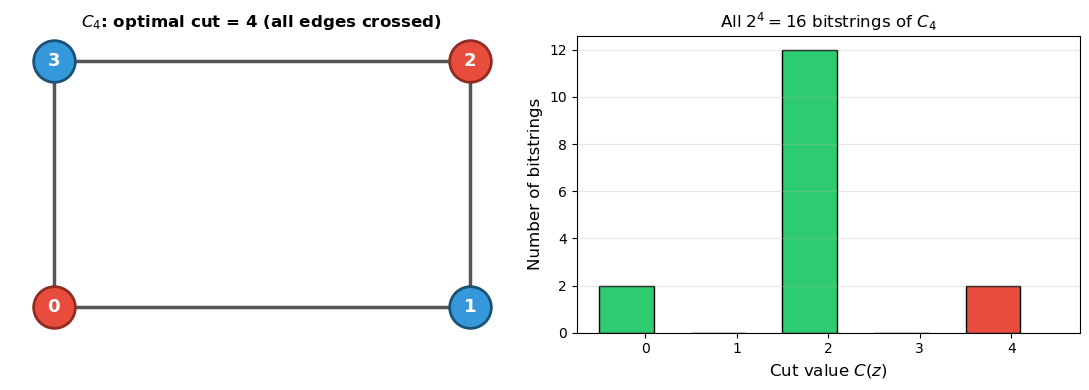

Max cut states: ['0101', '1010']


In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# C4: the running example throughout Part I
G_c4 = nx.cycle_graph(4)
pos  = {0:(0,0), 1:(1,0), 2:(1,1), 3:(0,1)}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Optimal 2-coloring
ax = axes[0]
nx.draw_networkx_nodes(G_c4, pos, nodelist=[0,2], ax=ax,
    node_color='#E74C3C', node_size=900, edgecolors='#922B21', linewidths=2)
nx.draw_networkx_nodes(G_c4, pos, nodelist=[1,3], ax=ax,
    node_color='#3498DB', node_size=900, edgecolors='#1A5276', linewidths=2)
nx.draw_networkx_edges(G_c4, pos, ax=ax, width=2.5, edge_color='#555')
nx.draw_networkx_labels(G_c4, pos, ax=ax, font_size=13, font_color='white', font_weight='bold')
ax.set_title(r'$C_4$: optimal cut = 4 (all edges crossed)', fontsize=12, fontweight='bold')
ax.axis('off')

# Distribution of C(z)
cuts = []
for z in range(16):
    bits = [(z>>i)&1 for i in range(4)]
    cuts.append(sum(bits[i]!=bits[j] for i,j in G_c4.edges()))

ax2 = axes[1]
vals, bins, patches = ax2.hist(cuts, bins=range(6), align='left',
    color='#2ECC71', edgecolor='black', width=0.6)
for patch, b in zip(patches, bins):
    if b == 4: patch.set_facecolor('#E74C3C')
ax2.set_xlabel(r'Cut value $C(z)$', fontsize=12)
ax2.set_ylabel('Number of bitstrings', fontsize=12)
ax2.set_title(r'All $2^4=16$ bitstrings of $C_4$', fontsize=12)
ax2.set_xticks(range(5))
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Max cut states: {[bin(z)[2:].zfill(4) for z in range(16) if cuts[z]==4]}')

---
## 2. Classical Ising Encoding

The **Ising model** on graph $G$ assigns a spin $s_i\in\{-1,+1\}$ to each vertex and measures energy by how (anti-)aligned neighbouring spins are:

$$H_{\text{Ising}} = -\sum_{(i,j)\in E} J_{ij}\,s_is_j$$

**Spin-to-bit conversion.** Set $s_i = 1-2z_i$, so:
- $z_i=0\Rightarrow s_i=+1$ (spin up, side $S$)
- $z_i=1\Rightarrow s_i=-1$ (spin down, side $\bar S$)

Then $s_is_j=+1$ when same side (not cut), $s_is_j=-1$ when opposite sides (cut), so:

$$\mathbf{1}[z_i\neq z_j] = \frac{1-s_is_j}{2}$$

Summing over all edges:

$$C(s) = \sum_{(i,j)\in E}\frac{1-s_is_j}{2} = \frac{|E|}{2} - \frac{1}{2}\underbrace{\sum_{(i,j)\in E}s_is_j}_{\text{Ising energy}}$$

**Key insight.** Maximising the cut $C(s)$ is exactly **minimising** the antiferromagnetic Ising energy $\sum_{(i,j)\in E} s_is_j$ with $J_{ij}=-1$. MaxCut is therefore equivalent to finding the ground state of an antiferromagnetic Ising model — a well-studied but computationally hard problem in statistical physics.

---
## 3. Quantum Hamiltonian via Pauli-Z

### 3.1 The substitution

In quantum mechanics, each qubit $i$ has a Pauli-Z operator:

$$Z_i = \begin{pmatrix}1&0\\0&-1\end{pmatrix}_i \otimes I_{\text{rest}}$$

On the computational basis: $Z_i|0\rangle_i = +1\cdot|0\rangle_i$ and $Z_i|1\rangle_i = -1\cdot|1\rangle_i$.

This means $Z_i$ acts on a basis state $|z\rangle$ exactly as the spin $s_i = 1-2z_i$:

$$Z_i|z\rangle = (-1)^{z_i}|z\rangle = s_i|z\rangle$$

So replacing $s_i\to Z_i$ is exact on the computational basis.

### 3.2 Cost Hamiltonian

$$\boxed{H_C = \sum_{(i,j)\in E}\frac{I - Z_iZ_j}{2}}$$

**Why this works.** For any basis state $|z\rangle$:

$$\frac{I-Z_iZ_j}{2}|z\rangle = \frac{1-(-1)^{z_i}(-1)^{z_j}}{2}|z\rangle = \frac{1-(-1)^{z_i+z_j}}{2}|z\rangle = \mathbf{1}[z_i\neq z_j]\,|z\rangle$$

So $H_C$ is **diagonal** in the computational basis with eigenvalue $C(z)$ on state $|z\rangle$.
Finding the ground state of $-H_C$ exactly solves MaxCut.

### 3.3 Mixer Hamiltonian

$$H_B = \sum_{i=0}^{n-1} X_i, \qquad X=\begin{pmatrix}0&1\\1&0\end{pmatrix}$$

$H_B$ does not commute with $H_C$ (since $[X_i,Z_i]\neq 0$). This non-commutativity is essential — it drives the quantum exploration between bitstrings. Since $X|+\rangle=|+\rangle$, the state $|+\rangle^{\otimes n}$ is the **maximum-eigenvalue eigenstate** of $H_B$ (equivalently, the ground state of $-H_B$); we take it as the QAOA starting state.

---
## 4. C4 — Explicit Hamiltonian

For $C_4$ with edges $(0,1),(1,2),(2,3),(3,0)$:

$$H_C^{C_4} = \frac{I-Z_0Z_1}{2}+\frac{I-Z_1Z_2}{2}+\frac{I-Z_2Z_3}{2}+\frac{I-Z_3Z_0}{2}$$

This is a 4-site antiferromagnetic Ising ring. The matrix $H_C$ is $16\times 16$ (acting on $\mathbb{C}^{2^4}$), but diagonal — the $(z,z)$ entry is $C(z)$.

In [2]:
I2 = np.eye(2)
Z  = np.array([[1.,0.],[0.,-1.]])

def kron_ZZ(n, i, j):
    """Build Z_i Z_j on n qubits."""
    ops = [I2]*n; ops[i] = Z; ops[j] = Z
    out = ops[0]
    for m in ops[1:]: out = np.kron(out, m)
    return out

n = 4; edges_c4 = [(0,1),(1,2),(2,3),(3,0)]
HC = sum(0.5*(np.eye(2**n) - kron_ZZ(n,i,j)) for i,j in edges_c4)

print('C4 cost Hamiltonian H_C — diagonal entries:')
for z in range(2**n):
    bits = ''.join(str((z>>k)&1) for k in range(n))
    mark = '  <-- max cut' if np.diag(HC)[z]==4 else ''
    print(f'  |{bits}>  ->  C = {np.diag(HC)[z]:.0f}{mark}')

C4 cost Hamiltonian H_C — diagonal entries:
  |0000>  ->  C = 0
  |1000>  ->  C = 2
  |0100>  ->  C = 2
  |1100>  ->  C = 2
  |0010>  ->  C = 2
  |1010>  ->  C = 4  <-- max cut
  |0110>  ->  C = 2
  |1110>  ->  C = 2
  |0001>  ->  C = 2
  |1001>  ->  C = 2
  |0101>  ->  C = 4  <-- max cut
  |1101>  ->  C = 2
  |0011>  ->  C = 2
  |1011>  ->  C = 2
  |0111>  ->  C = 2
  |1111>  ->  C = 0


---
## 5. QAOA Ansatz

QAOA applies $p$ alternating layers of two unitaries:

$$|\psi_p(\boldsymbol{\gamma},\boldsymbol{\beta})\rangle = U_B(\beta_p)U_C(\gamma_p)\cdots U_B(\beta_1)U_C(\gamma_1)|+\rangle^{\otimes n}$$

- **Cost unitary:** $U_C(\gamma)=e^{-i\gamma H_C}$ — adds phases proportional to cut value
- **Mixer unitary:** $U_B(\beta)=e^{-i\beta H_B}$ — mixes amplitudes between bitstrings

**Objective:** choose $\boldsymbol{\gamma},\boldsymbol{\beta}\in\mathbb{R}^p$ to maximise

$$F_p(\boldsymbol{\gamma},\boldsymbol{\beta}) = \langle\psi_p|H_C|\psi_p\rangle$$

**Gate count** per layer on $C_4$ ($|E|=4$, $n=4$):

| Unitary | Gates | Count |
|---------|-------|-------|
| $U_C(\gamma)$ | CNOT–$R_Z$–CNOT per edge | $8$ CNOT $+$ $4$ $R_Z$ |
| $U_B(\beta)$ | $R_X(2\beta)$ per qubit | $4$ $R_X$ |

Total CX gates for $p$ layers: $8p$.

---
## 6. Why Start from $|+\rangle^{\otimes n}$?

Three reasons:

**1. Maximum-eigenvalue eigenstate of $H_B$.** Since $X|+\rangle = |+\rangle$, the state $|+\rangle^{\otimes n}$ satisfies $H_B|+\rangle^{\otimes n} = n|+\rangle^{\otimes n}$. It is the maximum-eigenvalue state of $H_B$ — the state most 'aligned' with the mixer. Starting here makes the first mixer layer as effective as possible.

**2. Uniform superposition over all candidates.** $|+\rangle^{\otimes n} = \frac{1}{\sqrt{2^n}}\sum_{z\in\{0,1\}^n}|z\rangle$ is an equal-weight superposition of all $2^n$ bitstrings. No candidate solution is preferred at the start — maximum uncertainty.

**3. Efficient preparation.** $|+\rangle^{\otimes n} = H^{\otimes n}|0\rangle^{\otimes n}$ requires exactly $n$ Hadamard gates. The computational basis state $|0\rangle^{\otimes n}$ is the natural hardware initialisation.

**Adiabatic connection.** Define the interpolating Hamiltonian $H(t) = -(1-t/T)\,H_B - (t/T)\,H_C$ so that QAOA-as-MaxCut is *minimisation* throughout. Then $|+\rangle^{\otimes n}$ is the ground state of $H(0)=-H_B$, and the MaxCut bitstring is the ground state of $H(T)=-H_C$. QAOA with $p$ layers is a Trotterised approximation to this adiabatic path.

---
## 7. Measurement and the Shot Model

**How QAOA produces an answer.** After preparing $|\psi_p\rangle$, we measure each qubit in the computational basis. The outcome is a bitstring $z\in\{0,1\}^n$ with probability $|\langle z|\psi_p\rangle|^2$.

**Shots.** A single run of the circuit gives one bitstring. Repeating $S$ times gives $S$ independent samples. The empirical average of $C(z)$ over these samples estimates $F_p$:

$$\hat{F}_p = \frac{1}{S}\sum_{s=1}^{S}C(z^{(s)}), \qquad z^{(s)}\sim |\langle z|\psi_p\rangle|^2$$

By the law of large numbers, $\hat{F}_p\to F_p$ as $S\to\infty$.

**Estimation error.** By Hoeffding's inequality (since $0\leq C(z)\leq|E|$):

$$\Pr[|\hat{F}_p - F_p|\geq\epsilon] \leq 2\exp\!\left(-\frac{2S\epsilon^2}{|E|^2}\right)$$

So to get error $\leq\epsilon$ with probability $\geq 1-\delta$, we need $S\geq \frac{|E|^2}{2\epsilon^2}\ln\frac{2}{\delta}$ shots.

**Statevector simulation** (what we use in these notebooks) is the $S\to\infty$ limit: it computes $F_p$ exactly from $|\psi_p\rangle$ without sampling. On real hardware, $S$ is finite (typically $1000$–$10000$).

---
## References

- Karp, R. *Reducibility among combinatorial problems.* 1972.
- Farhi, Goldstone, Gutmann. arXiv:1411.4028 (2014).
- Goemans, Williamson. *JACM* 42(6), 1995.